# Phase 2 — Digital-twin degradation simulator & augmentation

Phase 1's EDA showed fewer than 1 in 10 training cycles represent an engine
actually close to failure (RUL ≤ 20). This notebook covers the simulator
built to address that, and the before/after evaluation of augmenting
training data with it.

**Design, in one paragraph:** a real fault (e.g. HPC wear) shows up as a
correlated shift across several sensors at once, not one sensor drifting
independently of the others. So the simulator gives each synthetic engine
ONE latent "decline rate" that drives every sensor's degradation curve
together, plus a per-sensor manufacturing offset (the calibration spread
already visible at the start of life, before degradation begins), plus
per-cycle sensor noise. All four ingredients — curve shape, decline-rate
distribution, offset distribution, noise level — are estimated from real
FD001 training data, then resampled to synthesize complete run-to-failure
trajectories for engines that never existed. See
`src/guardian/simulator/engine_simulator.py` for the implementation.

In [1]:
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from guardian.data.labeling import add_train_rul
from guardian.data.loader import load_train
from guardian.simulator.engine_simulator import EngineSimulator, TRENDING_SENSORS
from guardian.simulator.health_index import degradation_progress

real = add_train_rul(load_train("FD001"), clip=None)
sim = EngineSimulator().fit(real)
print(f"Fit on {real['unit_number'].nunique()} real engines, {len(TRENDING_SENSORS)} trending sensors.")
print(f"Decline-rate multiplier range across real engines: [{sim.rate_multipliers.min():.2f}, {sim.rate_multipliers.max():.2f}]")

Fit on 100 real engines, 14 trending sensors.
Decline-rate multiplier range across real engines: [0.30, 2.42]


## 1. What the fitted curves look like

For each trending sensor, `fit()` pools all real (degradation progress,
sensor value) pairs and fits `sensor(d) = a + b*(exp(k*d) - 1)` — flat at
baseline `a` while healthy, curving away as `d` (0=healthy, 1=failure)
increases. This is the standard exponential-wear shape used in the original
PHM08 degradation modeling (Saxena et al.).

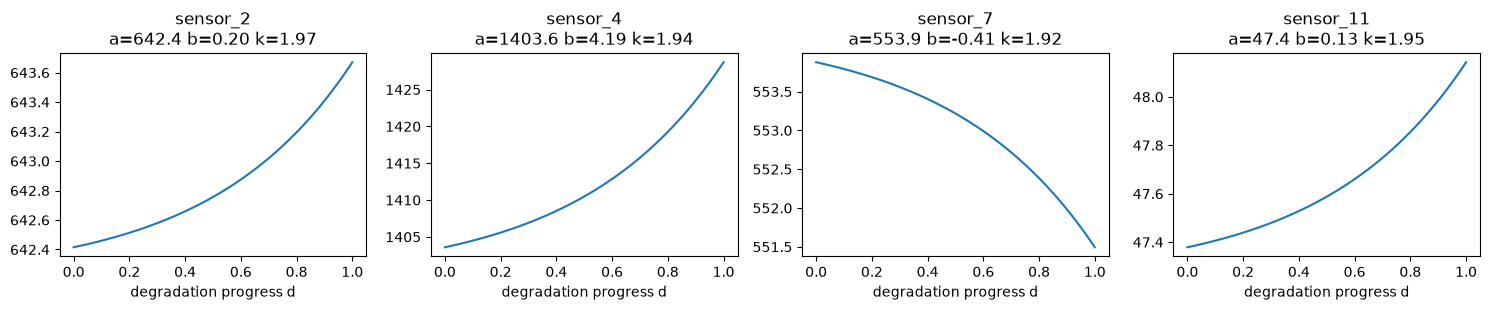

In [2]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.2))
d_grid = np.linspace(0, 1, 100)
for ax, sensor in zip(axes, ["sensor_2", "sensor_4", "sensor_7", "sensor_11"]):
    curve = sim.curves[sensor]
    ax.plot(d_grid, curve(d_grid))
    ax.set_title(f"{sensor}\na={curve.a:.1f} b={curve.b:.2f} k={curve.k:.2f}")
    ax.set_xlabel("degradation progress d")
fig.tight_layout()

## 2. Plausibility check: real vs. synthetic trajectories

Before trusting any downstream training results, the basic question is
"does this even look like a turbofan degrading?" Twenty synthetic engines
plotted against twenty real ones, aligned by cycles-to-failure so different
lifetimes line up at the point that matters:

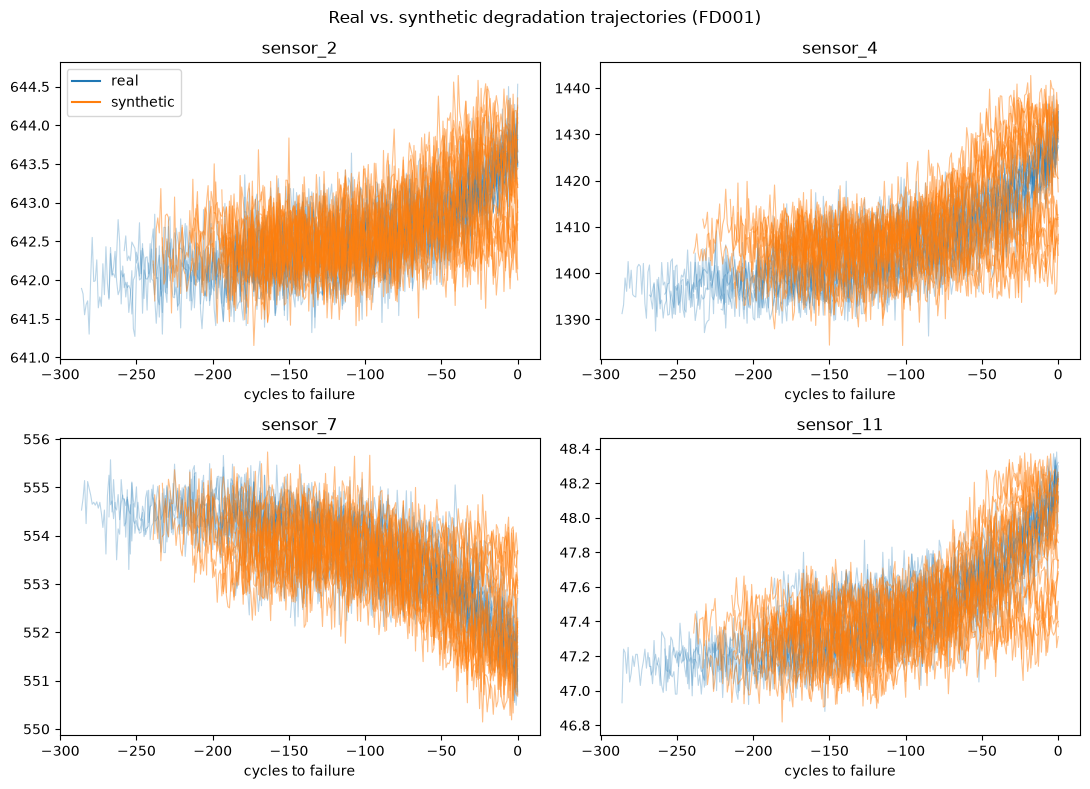

In [3]:
synthetic = sim.sample(n_engines=20, start_unit_id=1000, random_state=42)

sensors = ["sensor_2", "sensor_4", "sensor_7", "sensor_11"]
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
real_units = real["unit_number"].unique()[:15]
synth_units = synthetic["unit_number"].unique()

for ax, sensor in zip(axes.flat, sensors):
    for u in real_units:
        udf = real[real["unit_number"] == u]
        ax.plot(-udf["RUL"], udf[sensor], color="C0", alpha=0.3, linewidth=0.8)
    for u in synth_units:
        udf = synthetic[synthetic["unit_number"] == u]
        cycles_to_failure = -(len(udf) - udf["time_cycles"])
        ax.plot(cycles_to_failure, udf[sensor], color="C1", alpha=0.5, linewidth=0.8)
    ax.set_title(sensor)
    ax.set_xlabel("cycles to failure")
axes.flat[0].plot([], [], color="C0", label="real")
axes.flat[0].plot([], [], color="C1", label="synthetic")
axes.flat[0].legend()
fig.suptitle("Real vs. synthetic degradation trajectories (FD001)")
fig.tight_layout()

The synthetic bands track the real trend and sit in the same envelope of
noise — not narrower (which would mean "too clean to be useful for
augmentation") and not visibly wider (which would mean the noise model is
overstated). Getting here took one real fix: the first version of the noise
estimator used the raw curve-fit residual, which also captured curve-misfit
(a single shared decline-rate can't perfectly track every sensor's real
trajectory), not just true sensor noise — it made synthetic trajectories
visibly fuzzier than real ones. Estimating noise from **consecutive-cycle
differences** of the residual instead (which cancels the slow-varying
misfit and isolates the high-frequency noise) fixed it. See the
`resid_diffs` comment in `engine_simulator.py`.

## 3. The bias knob: skewing toward fast-failing engines

`short_life_quantile` bootstraps synthetic lifetimes only from the shortest
fraction of the real lifetime distribution — directly increasing the share
of near-failure cycles in the augmented set, rather than just adding more
"looks like the real data" volume.

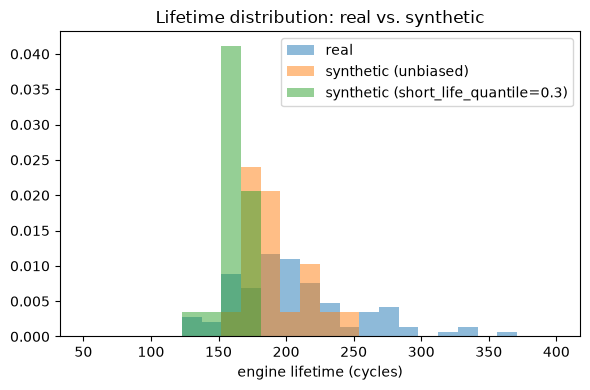

In [4]:
synthetic_short = sim.sample(n_engines=20, start_unit_id=2000, short_life_quantile=0.3, random_state=42)

fig, ax = plt.subplots(figsize=(6, 4))
real_life = real.groupby("unit_number").size()
synth_life = synthetic.groupby("unit_number").size()
synth_short_life = synthetic_short.groupby("unit_number").size()
bins = np.linspace(50, 400, 25)
ax.hist(real_life, bins=bins, alpha=0.5, label="real", density=True)
ax.hist(synth_life, bins=bins, alpha=0.5, label="synthetic (unbiased)", density=True)
ax.hist(synth_short_life, bins=bins, alpha=0.5, label="synthetic (short_life_quantile=0.3)", density=True)
ax.set_xlabel("engine lifetime (cycles)")
ax.legend()
ax.set_title("Lifetime distribution: real vs. synthetic")
fig.tight_layout()

## 4. Before / after: does augmentation actually help?

Two augmented training configs were run against the same FD001 baselines
from Phase 1 (`configs/gbm_fd001_aug_{moderate,aggressive}.yaml` and the
`lstm_fd001_aug_*` equivalents — `moderate` = 50 synthetic engines,
`short_life_quantile=0.5`; `aggressive` = 100 engines,
`short_life_quantile=0.3`, `rate_boost=1.2`). Synthetic engines are added
**only to the training fold**, never the validation or the official test
set, so this is a fair apples-to-apples comparison — see
`augment_fit_split()` in `scripts/train.py`.

| Model | Config | Test RMSE | Imminent-failure recall |
|---|---|---|---|
| GBM  | baseline       | 17.76 | 0.62 |
| GBM  | +aug moderate  | 18.16 | 0.56 |
| GBM  | +aug aggressive| 19.38 | 0.62 |
| LSTM | baseline       | 22.34 | 0.75 |
| LSTM | +aug moderate  | **16.87** | **0.81** |
| LSTM | +aug aggressive| 17.90 | 0.75 |

**The result is genuinely mixed, and that's the honest finding worth
reporting:**

- **LSTM: augmentation clearly helps.** RMSE drops 25% (22.3 → 16.9) and
  imminent-failure recall improves. Neural nets are data-hungry, and 50
  synthetic engines meaningfully grow the number of sliding-window training
  examples the LSTM sees near failure. Recall peaks at *moderate*
  augmentation and gives a little back at *aggressive* — a plausible
  saturation point rather than runaway improvement, which is more
  believable than monotonic gains all the way out.
- **GBM: augmentation slightly hurts, and it gets worse with more
  synthetic data.** FD001 is the "clean" subset GBM already fits well from
  100 real engines; adding synthetic trajectories — which are a good but
  imperfect approximation of the real physics — introduces mismatch that a
  tree model, unlike the LSTM, doesn't have a way to average out over many
  more parameters. The consistent monotonic degradation (moderate → worse
  than baseline, aggressive → worse still) suggests this isn't noise, it's
  a real effect of the model class.

**Implication:** synthetic-data augmentation is not a universal fix — its
value depends on how data-hungry the downstream model is and how well the
real baseline was already doing. For Guardian specifically, this argues for
using the simulator's augmented data selectively (here, for the LSTM) and
for evaluation always driving the decision — which is exactly the kind of
judgment call Phase 3's debate/judge mechanism should be making about
*retraining* decisions too.